In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
from src.squarenet.sampler import list_methods, samplepoints, place_at, plotpoints
from squarenet import SquareNet

Testing rotation

In [27]:
points = (np.load("src/squarenet/data/france.npy") - 16370).astype(float)
points = points[np.random.choice(1_000_000, size = 40_000)]
print(points.max())
print(points.min())

points = samplepoints("ball", size = (40_000, 2))

16368.0
-16232.0


succesfully sorted at iteration 14


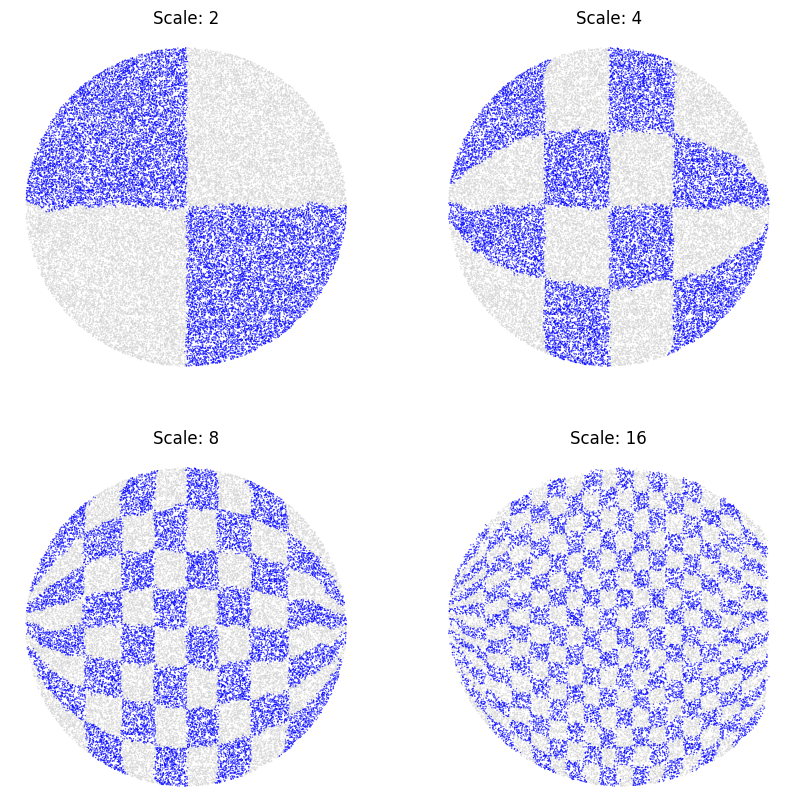

In [28]:
sqn = SquareNet(IJ_ = (200, 200))
sqn.fit(points)
sqn.checkerboard()

succesfully sorted at iteration 14
succesfully sorted at iteration 6
succesfully sorted at iteration 8
succesfully sorted at iteration 19
succesfully sorted at iteration 34
succesfully sorted at iteration 74


C:\Users\arman\AppData\Local\Temp\ipykernel_14340\841892049.py:8: ConvergenceWarning: Disorder didn't converge to 0. Check the learning curve and consider increasing the max_iter parameter.
  sqn.fit(pts)
C:\Users\arman\AppData\Local\Temp\ipykernel_14340\841892049.py:12: ConvergenceWarning: Disorder didn't converge to 0. Check the learning curve and consider increasing the max_iter parameter.
  sqn.fit(points)


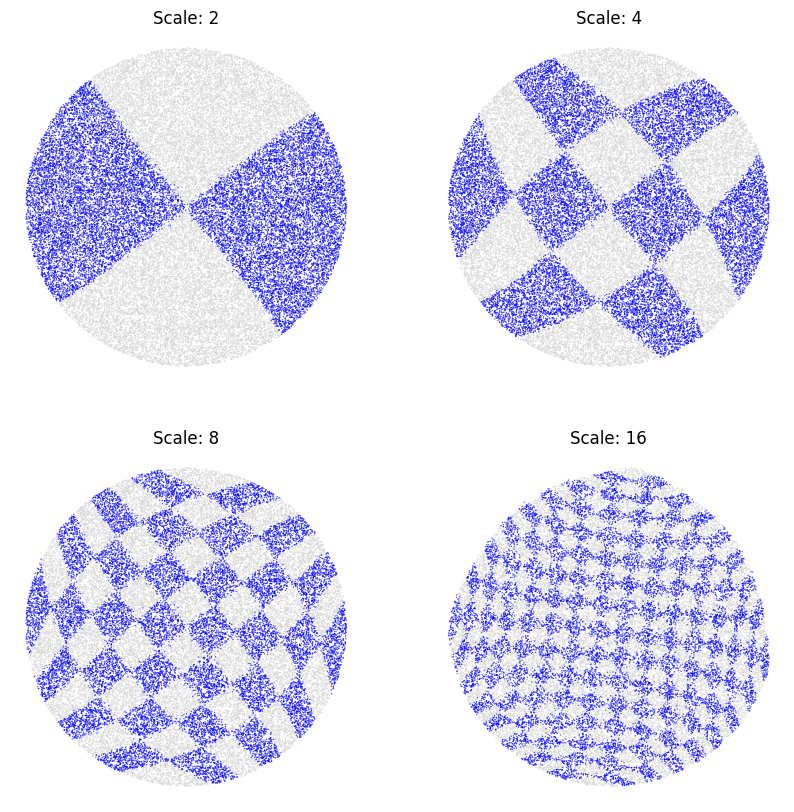

In [29]:
n_iter = 100

for i in range(100):
    theta = 2*np.pi*(i/100) 
    R = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    pts = points @ R
    sqn = SquareNet(IJ_ = (200, 200))
    sqn.fit(pts)
    points = sqn.map(points).reshape(-1, 2)

sqn = SquareNet(IJ_ = (200, 200))
sqn.fit(points)
sqn.checkerboard()

Testing compression

(360000, 2)
(2, 600, 600)


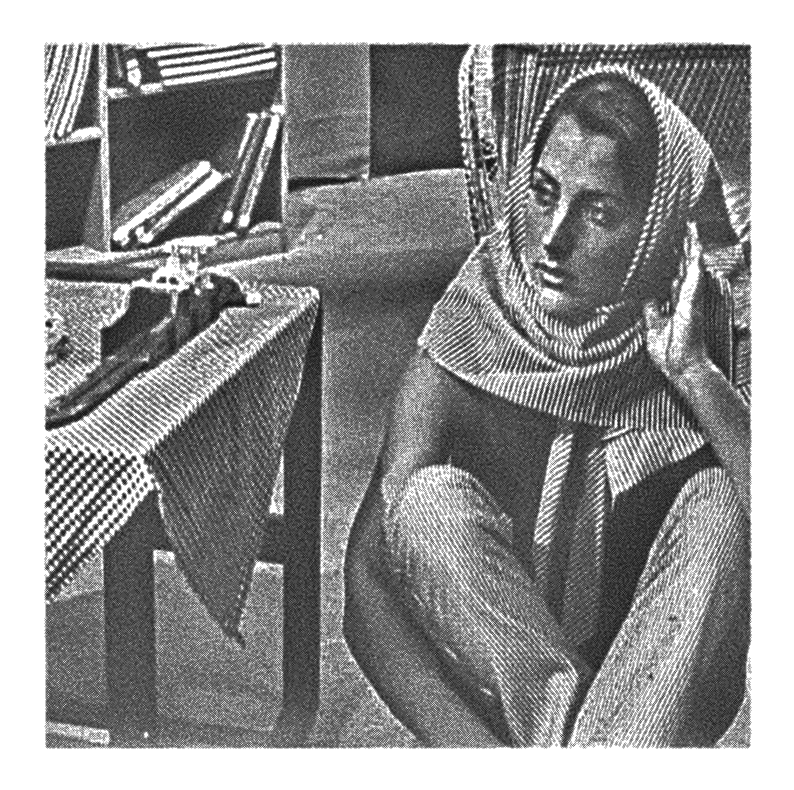

In [30]:
points = np.load("src/squarenet/data/barbara.npy")

psvd = points.astype(float).reshape(600, 600, 2).transpose((2, 0, 1))

print(points.shape)
print(psvd.shape)

k = 600

U, S, Vh = np.linalg.svd(psvd)
prec = ((U[:, :, :k] * S[:, None, :k]) @ Vh[:, :k]).transpose((1, 2, 0)).reshape(-1, 2)

plotpoints(prec)

In [31]:
list_methods()

['square',
 'ball',
 'ring',
 'gaussian',
 'spiky',
 'holy',
 'barbara',
 'lena',
 'france',
 'germany',
 'everest']

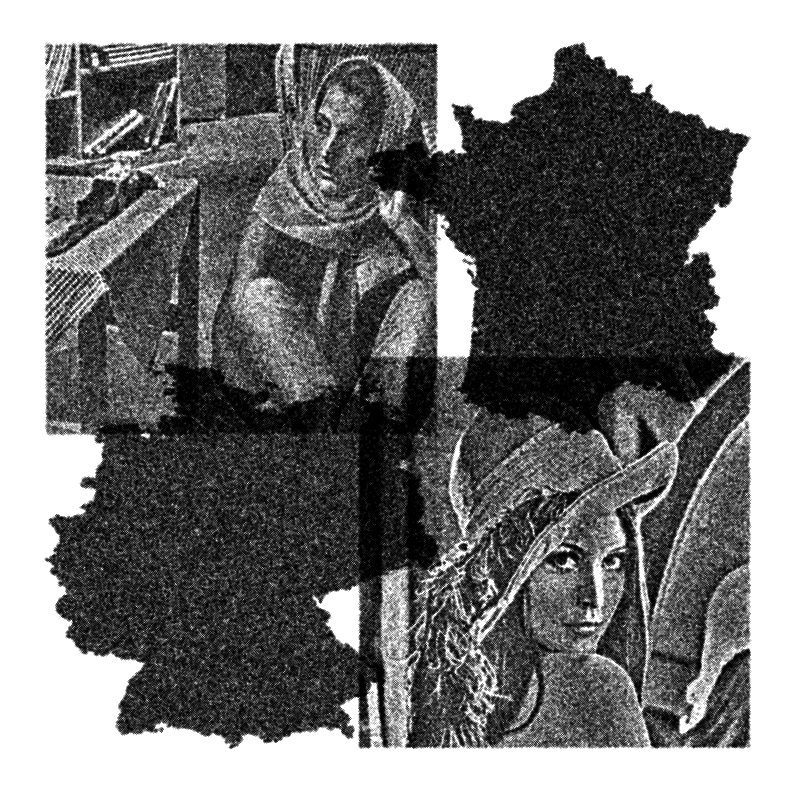

In [32]:
N = 1_000_000
methods = ["germany", "barbara", "lena", "france"]
positions = [(0, 0), (0, 0.8), (0.8,0), (0.8, 0.8)]

points = np.zeros((0, 2))
for met, pos in zip(methods, positions):
    p = samplepoints(method = met, size = (N//4, 2))
    p = place_at(p, pos)
    points = np.concatenate([points, p], axis = 0)

plotpoints(points)